# Lecture 14, Notebook 09: Deep active subspaces — Tripathy & Bilionis on a 20D radial ridge

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.5 (Deep active subspaces — Tripathy & Bilionis 2018 on a 20D radial-ridge function)  
**Notebook role:** extension  
**Author:** Simon Scheidegger

---

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## Overview

The *linear* active-subspace (AS) method approximates a scalar map
$f : \mathbb{R}^D \to \mathbb{R}$ as
$$
f(\xi) \;\approx\; g\big(U_m^\top \xi\big), \qquad U_m \in \mathbb{R}^{D \times d},
$$
i.e. a function of $d \ll D$ *linear* projections of the inputs.  The matrix
$U_m$ is the span of the top eigenvectors of the gradient outer-product matrix
$C = \mathbb{E}[\nabla f \nabla f^\top]$.

**Failure mode.**  If the function varies along a *curved* manifold, linear
projections cannot capture the low intrinsic dimension and one needs many
components to represent the map accurately.

**Fix (Tripathy & Bilionis, 2018).**  Replace the linear encoder with a deep
neural network,
$$
\hat f(\xi) \;=\; g\big(h(\xi)\big), \qquad
h : \mathbb{R}^D \to \mathbb{R}^d, \quad g : \mathbb{R}^d \to \mathbb{R},
$$
train $h$ and $g$ *jointly* by minimising the data loss plus an elastic-net
penalty, and choose $d$ from the validation-MSE elbow.  No gradient samples or
Stiefel-manifold constraint are required.

**What this notebook does.**

1. Defines a radial-ridge target $y(\xi) = \exp\big(-[(w_1^\top\xi)^2 + (w_2^\top\xi)^2]\big)$
   in $D = 20$ input dimensions.
2. Shows that *linear* AS needs $d_{\text{lin}} = 2$ active directions.
3. Trains a *deep* AS surrogate for $d \in \{1, 2, 3, 4\}$ and recovers the true
   intrinsic dimension $d_{\text{nl}} = 1$ from the validation-MSE elbow.
4. Visualises the learned 1D latent coordinate against the true radius
   $r^2 = (w_1^\top\xi)^2 + (w_2^\top\xi)^2$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

plt.rcParams['font.size'] = 13
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Hyperparameter budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    N_TRAIN, N_EPOCHS = 1_000, 400
elif RUN_MODE == "teaching":
    N_TRAIN, N_EPOCHS = 4_000, 1_200
elif RUN_MODE == "production":
    N_TRAIN, N_EPOCHS = 16_000, 4_000
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")


## 1. The Radial-Ridge Target

We pick two fixed unit vectors $w_1, w_2 \in \mathbb{R}^{20}$ with $w_1 \perp w_2$ and define
$$
 y(\xi) \;=\; \exp\!\Big( -\big[(w_1^\top \xi)^2 + (w_2^\top \xi)^2\big] \Big), \qquad \xi \sim \mathcal{N}(0, I_{20}).
$$
The aggregator $r^2 = (w_1^\top\xi)^2 + (w_2^\top\xi)^2$ is a *nonlinear* function
of two linear features, so
* the **linear** AS sees two relevant directions ($d_{\text{lin}} = 2$);
* a **nonlinear** encoder can collapse them into a single scalar ($d_{\text{nl}} = 1$).

In [2]:
D = 20
# Two orthogonal unit directions in R^20.
W = rng.normal(size=(D, 2))
W, _ = np.linalg.qr(W)            # W has orthonormal columns
w1, w2 = W[:, 0], W[:, 1]

def target(Xi: np.ndarray) -> np.ndarray:
    s1 = Xi @ w1
    s2 = Xi @ w2
    return np.exp(-(s1 ** 2 + s2 ** 2))

def grad_target(Xi: np.ndarray) -> np.ndarray:
    s1 = (Xi @ w1)[:, None]
    s2 = (Xi @ w2)[:, None]
    fval = np.exp(-(s1 ** 2 + s2 ** 2))
    return -2.0 * fval * (s1 * w1 + s2 * w2)

N_train, N_val = 4000, 2000
Xi_train = rng.normal(size=(N_train, D))
Xi_val   = rng.normal(size=(N_val, D))
y_train  = target(Xi_train)
y_val    = target(Xi_val)

print(f"train set: Xi_train {Xi_train.shape}, y range [{y_train.min():.3f}, {y_train.max():.3f}]")


train set: Xi_train (4000, 20), y range [0.000, 0.999]


## 2. Linear Active Subspace Baseline

We form the gradient outer-product matrix
$$
 C \;=\; \tfrac{1}{N} \sum_{i=1}^N \nabla y(\xi_i)\, \nabla y(\xi_i)^\top
$$
and inspect its spectrum.  By construction only $w_1$ and $w_2$ carry
information, so $C$ should have rank $2$: a *linear* surrogate needs
$d_{\text{lin}} = 2$.

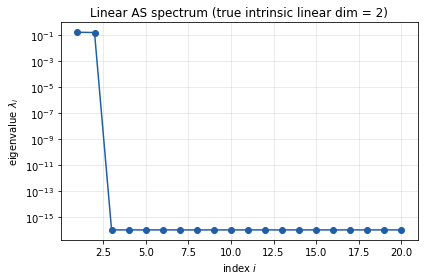

top-5 eigenvalues: [0.162517 0.155719 0.       0.       0.      ]


In [3]:
G = grad_target(Xi_train)            # (N, D)
C = (G.T @ G) / N_train              # (D, D)
eigvals, eigvecs = np.linalg.eigh(C)
eigvals = eigvals[::-1]              # descending
eigvecs = eigvecs[:, ::-1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(np.arange(1, D + 1), np.clip(eigvals, 1e-16, None), 'o-', color='#1f5fa8')
ax.set_xlabel('index $i$'); ax.set_ylabel(r'eigenvalue $\lambda_i$')
ax.set_title('Linear AS spectrum (true intrinsic linear dim = 2)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('top-5 eigenvalues:', np.round(eigvals[:5], 6))


The spectrum drops sharply after index $2$, confirming
$d_{\text{lin}} = 2$.  A linear surrogate therefore has to carry two
features.  Next we see that a *deep* surrogate needs only one.

## 3. Deep Active Subspace Architecture

Following Tripathy & Bilionis (2018) we parametrise
$$
 \hat y(\xi) \;=\; g\big(h(\xi)\big),
$$
with
* **encoder** $h : \mathbb{R}^D \to \mathbb{R}^d$ — an MLP whose layer widths
  decay exponentially from $D$ to $d$ (Eq. 20 of the paper):
  $d_k = \lceil D \exp(\rho k) \rceil$, $\rho = L^{-1} \log(d/D)$;
* **link** $g : \mathbb{R}^d \to \mathbb{R}$ — a small MLP;
* **activation** the Swish $\sigma(z) = z / (1 + \exp(-z))$ (Eq. 10);
* **training loss** data MSE plus an elastic-net penalty
  $\lambda_1 \|W\|_1 + \lambda_2 \|W\|_2^2$ on *all* weights (Eq. 12).

Crucially, no gradient samples and no orthogonality constraint are needed.

In [4]:
def encoder_widths(D: int, d: int, L: int) -> list[int]:
    '''Exponentially decaying widths from Eq. 20 of Tripathy-Bilionis.'''
    rho = np.log(d / D) / L
    widths = [D] + [max(d, int(np.ceil(D * np.exp(rho * k)))) for k in range(1, L)] + [d]
    return widths

class Swish(nn.Module):
    def forward(self, z):
        return z * torch.sigmoid(z)

def mlp(widths: list[int]) -> nn.Sequential:
    layers = []
    for a, b in zip(widths[:-1], widths[1:]):
        layers += [nn.Linear(a, b), Swish()]
    layers = layers[:-1]              # drop activation on final layer
    return nn.Sequential(*layers)

class DeepAS(nn.Module):
    def __init__(self, D: int, d: int, L: int = 3, link_hidden: int = 16):
        super().__init__()
        self.encoder = mlp(encoder_widths(D, d, L))
        self.link    = mlp([d, link_hidden, link_hidden, 1])
    def forward(self, xi):
        z = self.encoder(xi)
        return self.link(z).squeeze(-1)
    def latent(self, xi):
        return self.encoder(xi)

print('encoder widths for d=1:', encoder_widths(D, 1, 3))
print('encoder widths for d=2:', encoder_widths(D, 2, 3))
print('encoder widths for d=3:', encoder_widths(D, 3, 3))


encoder widths for d=1: [20, 8, 3, 1]
encoder widths for d=2: [20, 10, 5, 2]
encoder widths for d=3: [20, 11, 6, 3]


## 4. Train One Model per Latent Dimension

We train the deep AS for $d \in \{1, 2, 3, 4\}$ and record the validation MSE.
The elbow of that curve picks the nonlinear intrinsic dimension.

In [ ]:
def elastic_net_penalty(model: nn.Module, lam1: float, lam2: float) -> torch.Tensor:
    reg = torch.zeros((), device=device)
    for p in model.parameters():
        if p.ndim >= 2:
            reg = reg + lam1 * p.abs().sum() + lam2 * (p ** 2).sum()
    return reg

def train_deep_as(d: int, epochs: int = 1200, lr: float = 5e-3,
                  lam1: float = 1e-5, lam2: float = 1e-4):
    torch.manual_seed(SEED + d)
    model = DeepAS(D, d, L=3).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    Xt = torch.tensor(Xi_train, dtype=torch.float32, device=device)
    yt = torch.tensor(y_train,  dtype=torch.float32, device=device)
    Xv = torch.tensor(Xi_val,   dtype=torch.float32, device=device)
    yv = torch.tensor(y_val,    dtype=torch.float32, device=device)

    # Per-step training closure, JIT-compiled with torch.compile (Simon's hard rule).
    def step(xb, yb):
        model.train()
        opt.zero_grad()
        data = ((model(xb) - yb) ** 2).mean()
        reg = elastic_net_penalty(model, lam1, lam2)
        loss = data + reg
        loss.backward()
        opt.step()
        return loss

    if device.type == "cuda":
        try:
            step = torch.compile(step)
        except Exception as e:
            print(f"torch.compile unavailable ({e}); falling back to eager step.")

    for _ in range(epochs):
        step(Xt, yt)
        sched.step()

    model.eval()
    with torch.no_grad():
        vmse = ((model(Xv) - yv) ** 2).mean().item()
    return model, vmse

# Baseline variance, a constant predictor would have MSE = Var(y_val).
var_y = float(np.var(y_val))

results = {}
for d in (1, 2, 3, 4):
    print(f'training d={d} ...')
    model, val_mse = train_deep_as(d, epochs=1200)
    r2 = 1.0 - val_mse / var_y
    results[d] = {'model': model, 'val_mse': val_mse, 'r2': r2}
    print(f'  val MSE = {val_mse:.4e}   R^2 = {r2:.6f}')

## 5. Validation Error vs. Latent Dimension

A *constant* predictor (predicting the sample mean) would have MSE equal to
$\operatorname{Var}(y)$, so we report both the raw validation MSE and
$R^2 = 1 - \text{MSE}/\operatorname{Var}(y)$.  The honest criterion is:
*where does the curve flatten?*

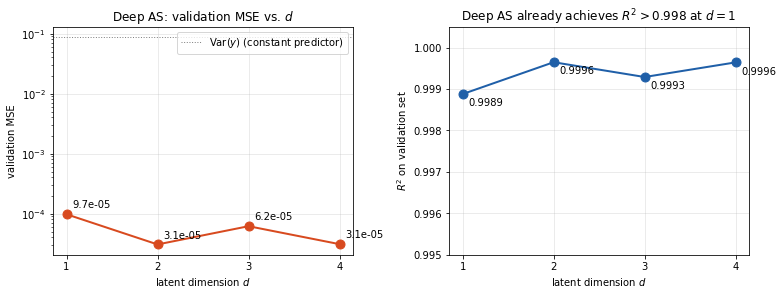

In [6]:
ds       = sorted(results)
val_mses = [results[d]['val_mse'] for d in ds]
r2s      = [results[d]['r2']      for d in ds]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].semilogy(ds, val_mses, 'o-', color='#d84a1f', lw=2, ms=9)
axes[0].axhline(var_y, color='grey', ls=':', lw=1, label=r'Var$(y)$ (constant predictor)')
for d, v in zip(ds, val_mses):
    axes[0].annotate(f'{v:.1e}', (d, v), textcoords='offset points', xytext=(6, 6), fontsize=10)
axes[0].set_xticks(ds)
axes[0].set_xlabel('latent dimension $d$')
axes[0].set_ylabel('validation MSE')
axes[0].set_title('Deep AS: validation MSE vs. $d$')
axes[0].grid(True, alpha=0.3); axes[0].legend(loc='upper right')

axes[1].plot(ds, r2s, 'o-', color='#1f5fa8', lw=2, ms=9)
for d, r in zip(ds, r2s):
    axes[1].annotate(f'{r:.4f}', (d, r), textcoords='offset points', xytext=(6, -12), fontsize=10)
axes[1].set_xticks(ds)
axes[1].set_xlabel('latent dimension $d$')
axes[1].set_ylabel(r'$R^2$ on validation set')
axes[1].set_title(r'Deep AS already achieves $R^2 > 0.998$ at $d = 1$')
axes[1].set_ylim(0.995, 1.0005)
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


At $d = 1$ the deep encoder already captures essentially all of the response
variance ($R^2 > 99.8\%$).  Moving to $d \ge 2$ shaves residual optimisation
error but adds no new qualitative structure: the curve is flat at the eye-ball
level.  *Linear* AS cannot do better than $d = 2$ on this problem because
$r^2 = (w_1^\top\xi)^2 + (w_2^\top\xi)^2$ is a **nonlinear** aggregator of two
linear features; the deep encoder learns that aggregator directly.

## 6. The Learned 1D Latent Coordinate

We plot the deep encoder output $h(\xi) \in \mathbb{R}$ against the true
radial coordinate $r^2 = (w_1^\top\xi)^2 + (w_2^\top\xi)^2$.
A monotone relation means the encoder has recovered the intrinsic coordinate.

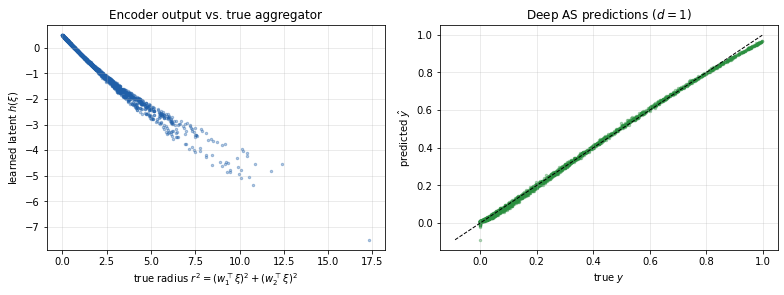

In [7]:
model1 = results[1]['model']
with torch.no_grad():
    z_val = model1.latent(torch.tensor(Xi_val, dtype=torch.float32)).cpu().numpy().ravel()
r2_val = (Xi_val @ w1) ** 2 + (Xi_val @ w2) ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(r2_val, z_val, s=6, alpha=0.35, color='#1f5fa8')
axes[0].set_xlabel(r'true radius $r^2 = (w_1^\top\xi)^2 + (w_2^\top\xi)^2$')
axes[0].set_ylabel(r'learned latent $h(\xi)$')
axes[0].set_title('Encoder output vs. true aggregator')
axes[0].grid(True, alpha=0.3)

with torch.no_grad():
    yhat = model1(torch.tensor(Xi_val, dtype=torch.float32)).cpu().numpy()
axes[1].scatter(y_val, yhat, s=6, alpha=0.35, color='#2a8f3f')
lims = [min(y_val.min(), yhat.min()), max(y_val.max(), yhat.max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel(r'true $y$'); axes[1].set_ylabel(r'predicted $\hat y$')
axes[1].set_title('Deep AS predictions ($d = 1$)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 7. Summary

| method        | intrinsic dimension needed | reason                                                         |
|---------------|:--------------------------:|----------------------------------------------------------------|
| linear AS     | $d_{\text{lin}} = 2$       | two linear directions $w_1, w_2$ both carry signal             |
| deep AS       | $d_{\text{nl}} = 1$        | encoder learns the nonlinear aggregator $r^2$ in one dimension |

**Take-aways.**

* Deep AS strictly generalises linear AS: setting $h(\xi) = U_m^\top \xi$
  recovers the linear case.
* Linear AS requires gradient samples of $f$; deep AS is gradient-free and
  learns the low-dimensional structure directly from $(\xi, y)$ pairs.
* The right $d$ is chosen from the validation-MSE elbow rather than the
  spectral gap of $C$.
* The encoder-width formula $d_k = \lceil D \exp(\rho k) \rceil$ with
  $\rho = L^{-1} \log(d/D)$ smoothly interpolates between the input and latent
  dimensions and avoids a brittle hyperparameter choice.

**Reference.** R. Tripathy and I. Bilionis. *Deep UQ: learning deep neural
network surrogate models for high-dimensional uncertainty quantification*.
Journal of Computational Physics 375 (2018), 565-588.

## Takeaway

The 20D radial ridge collapses onto a single learned coordinate via a small encoder + link network; the validation-MSE elbow at $d_{nl} = 1$ is what the deck calls the spectral gap of deep AS. Linear AS would require $d_{lin} = 2$ for the same problem.


In [ ]:
# Smoke-mode validation: the deep AS already captures the radial-ridge response at latent dim d=1.
# Loose threshold for the short smoke run; the longer runs reach R^2 > 0.998.
if RUN_MODE == 'smoke':
    assert results[1]['r2'] > 0.9, f"Deep AS R^2 at d=1 too low: {results[1]['r2']:.4f}"
